# 04 Sentiment & Theme Analysis

**Goal:** Analyse sentiment patterns across call types (internal vs customer-facing) and within customer-facing calls (support vs non-support).

This notebook covers:
- Builds a meeting-level DataFrame with `call_type`, `is_support_call`, `overall_sentiment`, `sentiment_score`, and `duration_minutes`
- Builds a turn-level DataFrame with per-turn sentiment labels
- Risk keyword analysis — flags meetings containing topics such as outage, churn, SLA breach, and compares their average sentiment score against non-risk meetings
- Comparison 1: internal vs customer-facing — meeting-level and turn-level sentiment distribution (ratio), average sentiment scores
- Comparison 2: support vs non-support within customer-facing — meeting-level and turn-level sentiment distribution (ratio), average sentiment scores
- Duration confound check — verifies whether call length differs across segments and could explain sentiment differences
- Score-to-label consistency check — confirms that sentiment labels (e.g. mixed-negative) align with numeric scores
- Topic-level analysis — which topics drive negativity in support calls, filtered to topics with at least 2 mentions
- Cluster sentiment in support calls — top 10 clusters by chunk count (min 4 chunks), sentiment distribution shown as ratio
- Sentiment progression through calls — turns normalised to relative position (0–1), binned into 10 deciles, averaged across all calls to show how sentiment shifts from start to end
- Last 3 turns sentiment — distribution of sentiment labels in the final 3 turns per call, compared across internal, customer-facing, support, and non-support


In [36]:
import json
from pathlib import Path

import pandas as pd


BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATASET_PATH = (
    BASE_DIR
    / "data"
    / "processed"
    /"clustered_chunks"
    / "named_clustered_dataset_with_support.json"
)

with open(DATASET_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

len(dataset)

100

In [37]:
rows = []

for meeting in dataset:
    meta = meeting.get("meeting_metadata", {})
    summary = meeting.get("summary_metadata", {})

    rows.append({
        "meeting_id": meeting.get("meeting_id"),
        "call_type": meta.get("call_type"),
        "is_support_call": meta.get("is_support_call"),
        "overall_sentiment": summary.get("overall_sentiment"),
        "sentiment_score": summary.get("sentiment_score"),
        "duration_minutes": meta.get("duration_minutes"),
        "title": meta.get("title")
    })

df = pd.DataFrame(rows)

df.head()

,meeting_id,call_type,is_support_call,overall_sentiment,sentiment_score,duration_minutes,title
0,01KQ03B0303900521BB089CA,internal_operational,False,mixed-negative,2.4,35.2,Detect Outage - Remediation Plan Review
1,01KQ0C1280EDA4E70AAD7C35,customer_facing,True,mixed-positive,3.8,23.8,Support Case #9279 - Summit Trust Billing Inquiry
2,01KQ0CAE7F064EC93F0540CA,internal_operational,False,mixed-positive,3.6,29.0,Weekly Engineering Standup
3,01KQ0DFE299AC7A74E8022CA,customer_facing,False,very-positive,4.8,28.8,Aegis / Redwood Clinical - ISO 27001 Preparation
4,01KQ0F8AFF3DA34FD4580008,customer_facing,False,mixed-positive,3.4,41.2,Aegis / Cobalt Software - Q2 Planning


In [38]:
turn_records = []

for meeting in dataset:

    call_type = meeting["meeting_metadata"]["call_type"]

    for turn in meeting.get("turns", []):

        turn_records.append({
            "meeting_id": meeting["meeting_id"],
            "call_type": call_type,
            "speaker": turn.get("speaker_name"),
            "sentiment": turn.get("sentiment"),
            "text": turn.get("text")
        })

turn_df = pd.DataFrame(turn_records)

turn_df.head()

,meeting_id,call_type,speaker,sentiment,text
0,01KQ03B0303900521BB089CA,internal_operational,Megan Lawson,neutral,"Alright, I think we're all on — Raj, Brian, ca..."
1,01KQ03B0303900521BB089CA,internal_operational,Raj Kapoor,neutral,"Yeah, I'm here. Audio's good."
2,01KQ03B0303900521BB089CA,internal_operational,Brian Cho,neutral,"Yep, I'm on. Give me one sec, I'm just pulling..."
3,01KQ03B0303900521BB089CA,internal_operational,Megan Lawson,neutral,"Sure, take your time. So, uh, the reason I wan..."
4,01KQ03B0303900521BB089CA,internal_operational,Raj Kapoor,neutral,"Yeah, agreed. I've been heads-down with the en..."


In [39]:
risk_keywords = [
    "outage",
    "sla breach",
    "incident",
    "churn",
    "billing dispute",
    "failure"
]

risk_rows = []

for meeting in dataset:

    topics = " ".join(
        meeting["summary_metadata"].get("provided_topics", [])
    ).lower()

    has_risk = any(
        keyword in topics
        for keyword in risk_keywords
    )

    risk_rows.append({
        "meeting_id": meeting["meeting_id"],
        "call_type": meeting["meeting_metadata"].get("call_type"),
        "sentiment_score": meeting["summary_metadata"].get("sentiment_score"),
        "has_risk_topic": has_risk
    })

risk_df = pd.DataFrame(risk_rows)

risk_analysis = (
    risk_df.groupby("has_risk_topic")["sentiment_score"]
           .mean()
)

print(risk_analysis)

has_risk_topic
False    4.107692
True     2.973770
Name: sentiment_score, dtype: float64


In [41]:
support_analysis = (
    df.groupby("is_support_call")["sentiment_score"]
      .agg(["count", "mean", "median", "std"])
)

support_analysis.index = [
    "non_support",
    "support"
]

print(support_analysis)

             count      mean  median       std
non_support     73  3.593151     3.6  1.004480
support         27  2.937037     2.4  0.857612


In [42]:
print(df["call_type"].value_counts())
print()
print(df[df["call_type"] == "customer_facing"]["is_support_call"].value_counts())


call_type
customer_facing         70
internal_operational    30
Name: count, dtype: int64

is_support_call
False    43
True     27
Name: count, dtype: int64


In [43]:
comp1 = df.groupby("call_type")["sentiment_score"].agg(["count", "mean", "median", "std"]).round(2)
print(comp1)


                      count  mean  median   std
call_type                                      
customer_facing          70  3.41    3.45  1.03
internal_operational     30  3.42    3.55  0.96


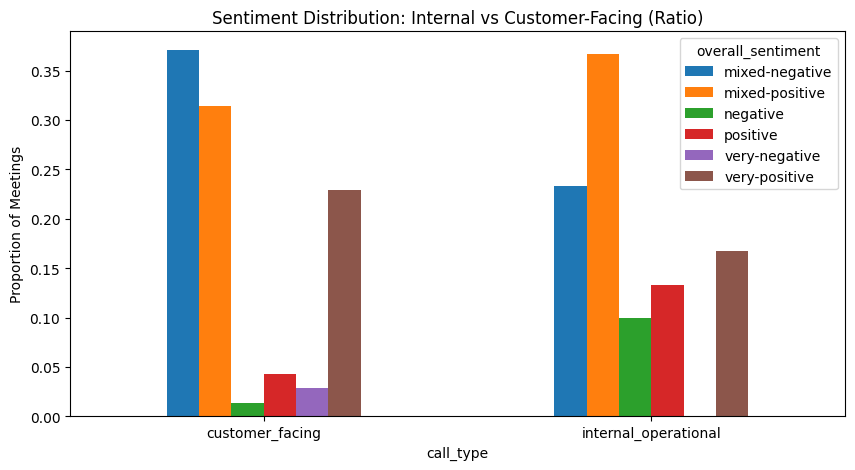

In [44]:
dist1 = (
    df.groupby(["call_type", "overall_sentiment"])
      .size()
      .unstack(fill_value=0)
)
dist1_ratio = dist1.div(dist1.sum(axis=1), axis=0).round(3)
dist1_ratio.plot(kind="bar", figsize=(10, 5))
plt.title("Sentiment Distribution: Internal vs Customer-Facing (Ratio)")
plt.ylabel("Proportion of Meetings")
plt.xticks(rotation=0)
plt.show()


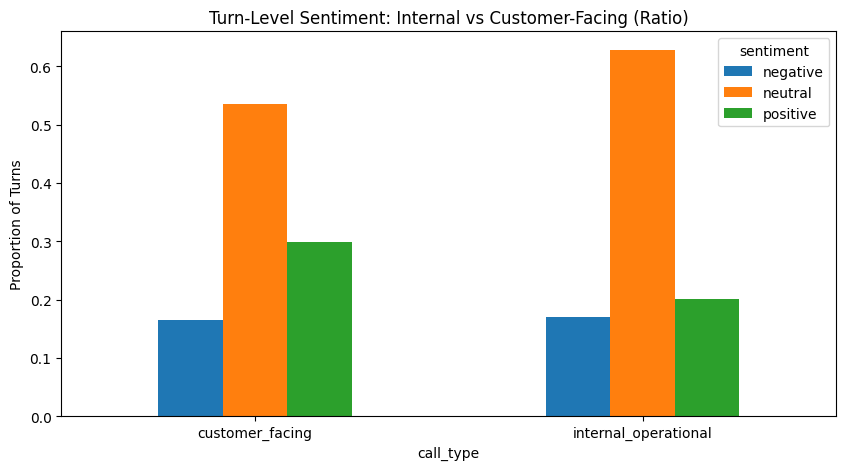

In [45]:
td1 = (
    turn_df.groupby(["call_type", "sentiment"])
           .size()
           .unstack(fill_value=0)
)
td1_ratio = td1.div(td1.sum(axis=1), axis=0).round(3)
td1_ratio.plot(kind="bar", figsize=(10, 5))
plt.title("Turn-Level Sentiment: Internal vs Customer-Facing (Ratio)")
plt.ylabel("Proportion of Turns")
plt.xticks(rotation=0)
plt.show()


In [46]:
cf_df = df[df["call_type"] == "customer_facing"].copy()
cf_df["support_label"] = cf_df["is_support_call"].map({True: "support", False: "non_support"})

comp2 = cf_df.groupby("support_label")["sentiment_score"].agg(["count", "mean", "median", "std"]).round(2)
print(comp2)


               count  mean  median   std
support_label                           
non_support       43  3.71     3.9  1.03
support           27  2.94     2.4  0.86


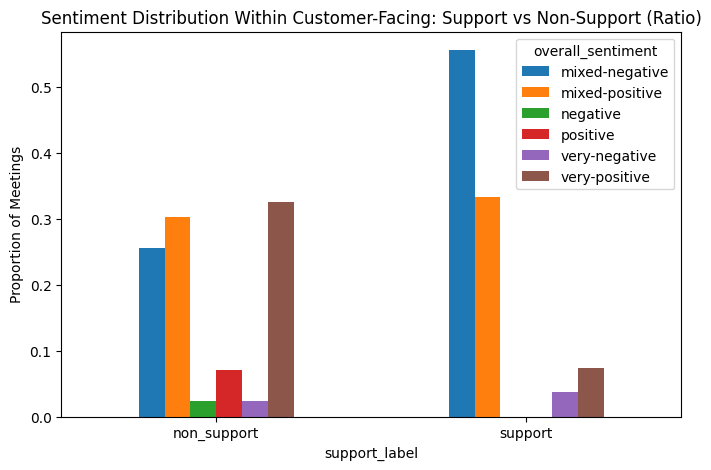

In [47]:
dist2 = (
    cf_df.groupby(["support_label", "overall_sentiment"])
         .size()
         .unstack(fill_value=0)
)
dist2_ratio = dist2.div(dist2.sum(axis=1), axis=0).round(3)
dist2_ratio.plot(kind="bar", figsize=(8, 5))
plt.title("Sentiment Distribution Within Customer-Facing: Support vs Non-Support (Ratio)")
plt.ylabel("Proportion of Meetings")
plt.xticks(rotation=0)
plt.show()


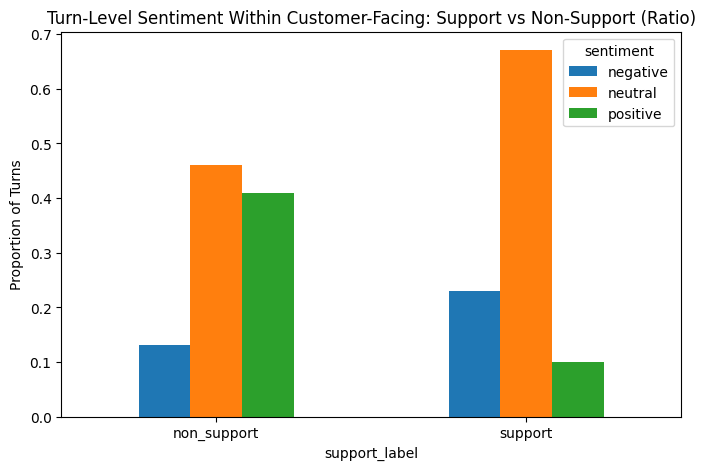

In [48]:
cf_turn_df = turn_df[turn_df["call_type"] == "customer_facing"].merge(
    df[["meeting_id", "is_support_call"]], on="meeting_id", how="left"
)
cf_turn_df["support_label"] = cf_turn_df["is_support_call"].map({True: "support", False: "non_support"})

td2 = (
    cf_turn_df.groupby(["support_label", "sentiment"])
              .size()
              .unstack(fill_value=0)
)
td2_ratio = td2.div(td2.sum(axis=1), axis=0).round(3)
td2_ratio.plot(kind="bar", figsize=(8, 5))
plt.title("Turn-Level Sentiment Within Customer-Facing: Support vs Non-Support (Ratio)")
plt.ylabel("Proportion of Turns")
plt.xticks(rotation=0)
plt.show()


In [49]:
print("=== call_type ===")
print(df.groupby("call_type")["duration_minutes"].agg(["count", "mean", "median"]).round(1))
print()
print("=== support vs non_support (within customer_facing) ===")
print(cf_df.groupby("support_label")["duration_minutes"].agg(["count", "mean", "median"]).round(1))


=== call_type ===
                      count  mean  median
call_type                                
customer_facing          70  29.9    28.7
internal_operational     30  31.4    30.4

=== support vs non_support (within customer_facing) ===
               count  mean  median
support_label                     
non_support       43  37.2    36.3
support           27  18.2    17.6


In [35]:
print(df.groupby("overall_sentiment")["sentiment_score"].agg(["mean", "median", "count"]).round(2).sort_values("mean"))


                   mean  median  count
overall_sentiment                     
very-negative      1.50     1.5      2
negative           1.80     1.8      4
mixed-negative     2.42     2.4     33
mixed-positive     3.66     3.6     33
positive           4.36     4.4      7
very-positive      4.77     4.8     21


In [50]:
topic_rows = []
for meeting in dataset:
    meta = meeting["meeting_metadata"]
    summary = meeting["summary_metadata"]
    for topic in summary.get("provided_topics", []):
        topic_rows.append({
            "topic": topic.lower().strip(),
            "is_support_call": meta.get("is_support_call"),
            "call_type": meta.get("call_type"),
            "sentiment_score": summary.get("sentiment_score"),
            "overall_sentiment": summary.get("overall_sentiment"),
        })

topic_df = pd.DataFrame(topic_rows)
print(f"Support topic mentions: {topic_df[topic_df['is_support_call']].shape[0]}")
print(f"Unique topics in support: {topic_df[topic_df['is_support_call']]['topic'].nunique()}")


Support topic mentions: 162
Unique topics in support: 127


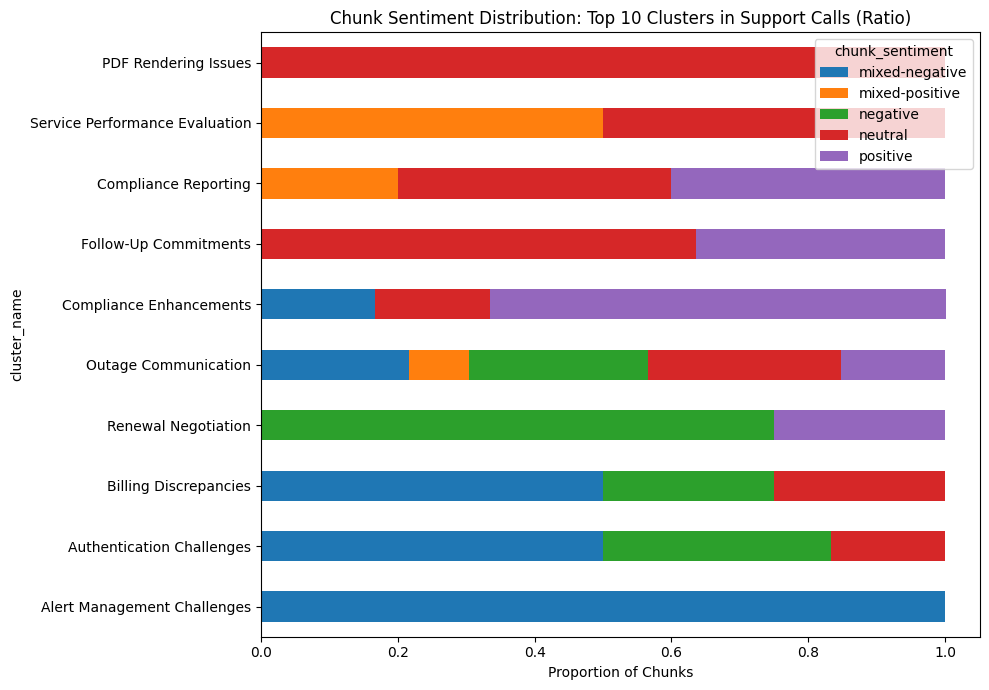

chunk_sentiment                 mixed-negative  mixed-positive  negative  \
cluster_name                                                               
Alert Management Challenges              1.000           0.000     0.000   
Authentication Challenges                0.500           0.000     0.333   
Billing Discrepancies                    0.500           0.000     0.250   
Renewal Negotiation                      0.000           0.000     0.750   
Outage Communication                     0.217           0.087     0.261   
Compliance Enhancements                  0.167           0.000     0.000   
Follow-Up Commitments                    0.000           0.000     0.000   
Compliance Reporting                     0.000           0.200     0.000   
Service Performance Evaluation           0.000           0.500     0.000   
PDF Rendering Issues                     0.000           0.000     0.000   

chunk_sentiment                 neutral  positive  
cluster_name                       

In [54]:
chunk_rows = []
for meeting in dataset:
    if not meeting["meeting_metadata"].get("is_support_call"):
        continue
    for chunk in meeting.get("semantic_chunks", []):
        chunk_rows.append({
            "cluster_name":    chunk.get("cluster_name"),
            "chunk_sentiment": chunk.get("chunk_sentiment"),
        })

chunk_df = pd.DataFrame(chunk_rows)

cluster_dist = (
    chunk_df.groupby(["cluster_name", "chunk_sentiment"])
            .size()
            .unstack(fill_value=0)
)

# only keep top 10 clusters by total chunk count
top10 = cluster_dist.sum(axis=1).nlargest(10).index
cluster_dist = cluster_dist.loc[top10]

cluster_ratio = cluster_dist.div(cluster_dist.sum(axis=1), axis=0).round(3)

neg_cols = [c for c in cluster_ratio.columns if "negative" in c]
cluster_ratio["neg_ratio"] = cluster_ratio[neg_cols].sum(axis=1)
cluster_ratio = cluster_ratio.sort_values("neg_ratio", ascending=False).drop(columns="neg_ratio")

cluster_ratio.plot(kind="barh", figsize=(10, 7), stacked=True)
plt.title("Chunk Sentiment Distribution: Top 10 Clusters in Support Calls (Ratio)")
plt.xlabel("Proportion of Chunks")
plt.tight_layout()
plt.show()

print(cluster_ratio)


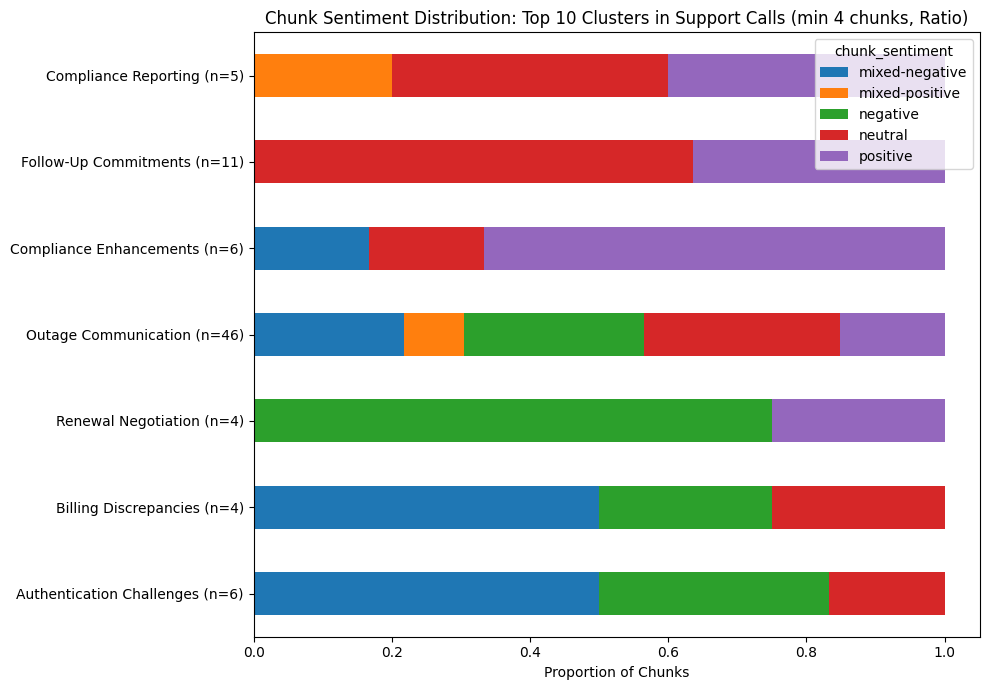

chunk_sentiment                  mixed-negative  mixed-positive  negative  \
Authentication Challenges (n=6)           0.500           0.000     0.333   
Billing Discrepancies (n=4)               0.500           0.000     0.250   
Renewal Negotiation (n=4)                 0.000           0.000     0.750   
Outage Communication (n=46)               0.217           0.087     0.261   
Compliance Enhancements (n=6)             0.167           0.000     0.000   
Follow-Up Commitments (n=11)              0.000           0.000     0.000   
Compliance Reporting (n=5)                0.000           0.200     0.000   

chunk_sentiment                  neutral  positive  
Authentication Challenges (n=6)    0.167     0.000  
Billing Discrepancies (n=4)        0.250     0.000  
Renewal Negotiation (n=4)          0.000     0.250  
Outage Communication (n=46)        0.283     0.152  
Compliance Enhancements (n=6)      0.167     0.667  
Follow-Up Commitments (n=11)       0.636     0.364  
Compliance R

In [56]:
chunk_rows = []
for meeting in dataset:
    if not meeting["meeting_metadata"].get("is_support_call"):
        continue
    for chunk in meeting.get("semantic_chunks", []):
        chunk_rows.append({
            "cluster_name":    chunk.get("cluster_name"),
            "chunk_sentiment": chunk.get("chunk_sentiment"),
        })

chunk_df = pd.DataFrame(chunk_rows)

cluster_dist = (
    chunk_df.groupby(["cluster_name", "chunk_sentiment"])
            .size()
            .unstack(fill_value=0)
)

# drop clusters with fewer than 4 chunks, then take top 10
cluster_counts = cluster_dist.sum(axis=1)
valid_clusters = cluster_counts[cluster_counts >= 4].nlargest(10).index
cluster_dist = cluster_dist.loc[valid_clusters]

cluster_ratio = cluster_dist.div(cluster_dist.sum(axis=1), axis=0).round(3)

neg_cols = [c for c in cluster_ratio.columns if "negative" in c]
cluster_ratio["neg_ratio"] = cluster_ratio[neg_cols].sum(axis=1)
cluster_ratio = cluster_ratio.sort_values("neg_ratio", ascending=False).drop(columns="neg_ratio")

chunk_counts = cluster_dist.sum(axis=1)
cluster_ratio.index = [f"{name} (n={chunk_counts[name]})" for name in cluster_ratio.index]

cluster_ratio.plot(kind="barh", figsize=(10, 7), stacked=True)
plt.title("Chunk Sentiment Distribution: Top 10 Clusters in Support Calls (min 4 chunks, Ratio)")
plt.xlabel("Proportion of Chunks")
plt.tight_layout()
plt.show()

print(cluster_ratio)


In [57]:
sentiment_map = {
    "positive":       5,
    "mixed-positive": 4,
    "neutral":        3,
    "mixed-negative": 2,
    "negative":       1,
}

progression_rows = []

for meeting in dataset:
    turns = meeting.get("turns", [])
    if not turns:
        continue

    is_support = meeting["meeting_metadata"].get("is_support_call")
    call_type = meeting["meeting_metadata"].get("call_type")
    label = "support" if is_support else ("internal" if call_type == "internal_operational" else "non_support_cf")

    times = [t.get("start_time", 0) for t in turns]
    min_t, max_t = min(times), max(times)
    duration = max_t - min_t if max_t > min_t else 1

    for turn in turns:
        score = sentiment_map.get(turn.get("sentiment"), 3)
        rel_pos = (turn.get("start_time", 0) - min_t) / duration
        progression_rows.append({
            "meeting_id":  meeting["meeting_id"],
            "label":       label,
            "rel_pos":     rel_pos,
            "score":       score,
        })

prog_df = pd.DataFrame(progression_rows)
prog_df["decile"] = pd.cut(prog_df["rel_pos"], bins=10, labels=range(1, 11))
print(prog_df.head())


                 meeting_id     label   rel_pos  score decile
0  01KQ03B0303900521BB089CA  internal  0.000000      3      1
1  01KQ03B0303900521BB089CA  internal  0.011851      3      1
2  01KQ03B0303900521BB089CA  internal  0.017381      3      1
3  01KQ03B0303900521BB089CA  internal  0.030022      3      1
4  01KQ03B0303900521BB089CA  internal  0.068931      3      1


/var/folders/jf/7cvyp7b11r9gr1394g_p3mhm0000gn/T/ipykernel_74250/505203348.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cf_prog.groupby(["label", "decile"])["score"]


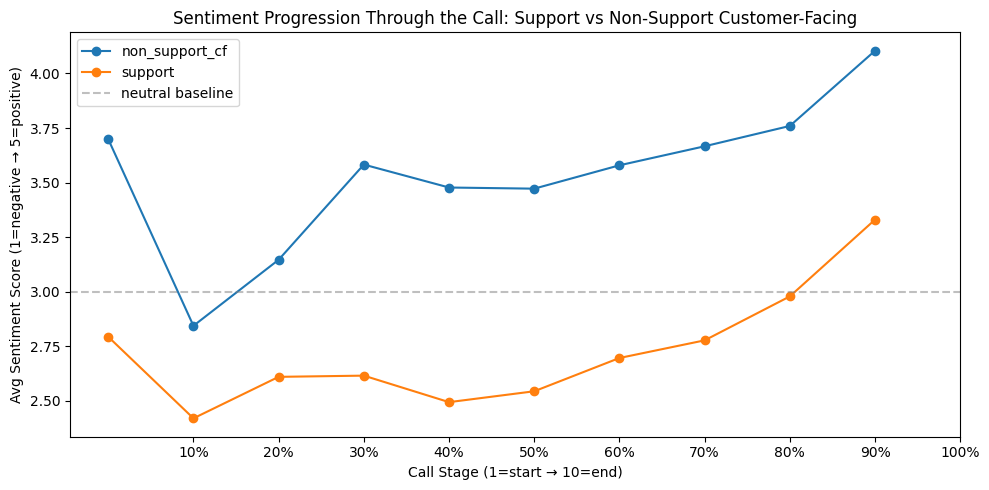

In [58]:
cf_prog = prog_df[prog_df["label"].isin(["support", "non_support_cf"])]

progression = (
    cf_prog.groupby(["label", "decile"])["score"]
           .mean()
           .unstack("label")
)

progression.plot(kind="line", figsize=(10, 5), marker="o")
plt.title("Sentiment Progression Through the Call: Support vs Non-Support Customer-Facing")
plt.xlabel("Call Stage (1=start → 10=end)")
plt.ylabel("Avg Sentiment Score (1=negative → 5=positive)")
plt.xticks(range(1, 11), [f"{i*10}%" for i in range(1, 11)])
plt.axhline(y=3, color="grey", linestyle="--", alpha=0.5, label="neutral baseline")
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/jf/7cvyp7b11r9gr1394g_p3mhm0000gn/T/ipykernel_74250/3499390732.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_prog.groupby(["segment", "decile"])["score"]


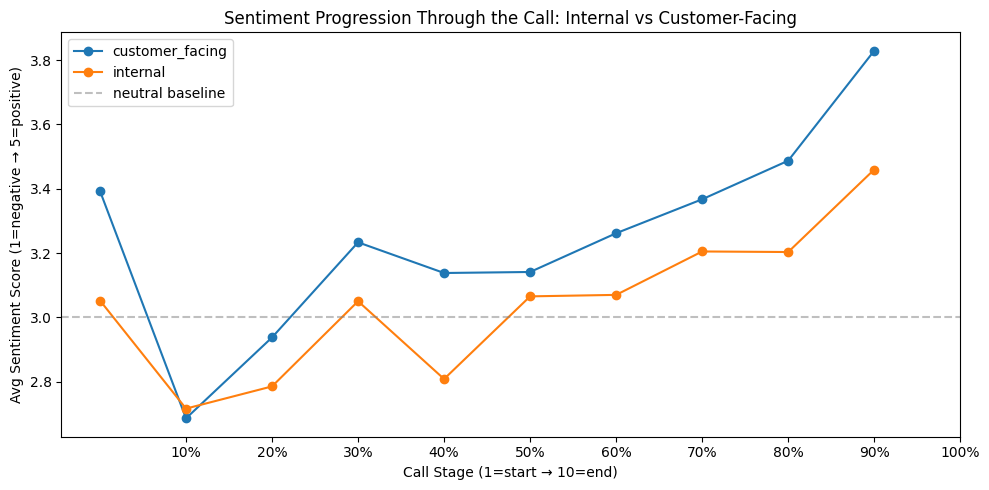

In [60]:
ct_prog = prog_df[prog_df["label"].isin(["internal", "non_support_cf", "support"])]

# combine support and non_support_cf into one customer_facing group
ct_prog = ct_prog.copy()
ct_prog["segment"] = ct_prog["label"].map({
    "internal":      "internal",
    "support":       "customer_facing",
    "non_support_cf":"customer_facing",
})

ct_progression = (
    ct_prog.groupby(["segment", "decile"])["score"]
           .mean()
           .unstack("segment")
)

ct_progression.plot(kind="line", figsize=(10, 5), marker="o")
plt.title("Sentiment Progression Through the Call: Internal vs Customer-Facing")
plt.xlabel("Call Stage (1=start → 10=end)")
plt.ylabel("Avg Sentiment Score (1=negative → 5=positive)")
plt.xticks(range(1, 11), [f"{i*10}%" for i in range(1, 11)])
plt.axhline(y=3, color="grey", linestyle="--", alpha=0.5, label="neutral baseline")
plt.legend()
plt.tight_layout()
plt.show()


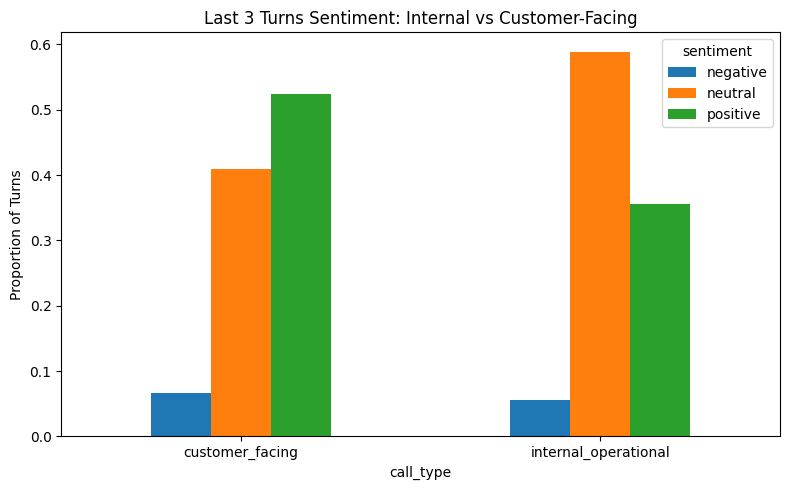

sentiment             negative  neutral  positive
call_type                                        
customer_facing          0.067    0.410     0.524
internal_operational     0.056    0.589     0.356


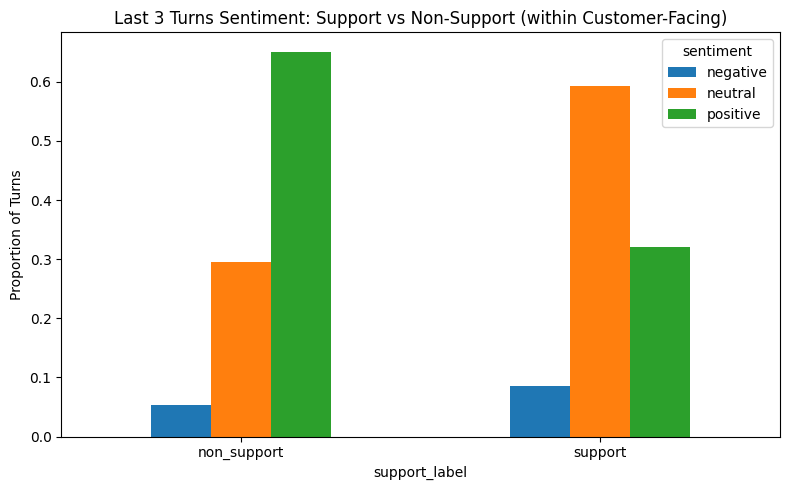

sentiment      negative  neutral  positive
support_label                             
non_support       0.054    0.295     0.651
support           0.086    0.593     0.321


In [63]:
last_turn_rows = []

for meeting in dataset:
    turns = meeting.get("turns", [])
    if not turns:
        continue

    meta = meeting["meeting_metadata"]
    is_support = meta.get("is_support_call")
    call_type = meta.get("call_type")

    sorted_turns = sorted(turns, key=lambda t: t.get("start_time", 0))
    last_3 = sorted_turns[-3:]

    for turn in last_3:
        last_turn_rows.append({
            "call_type":     call_type,
            "support_label": "support" if is_support else "non_support",
            "sentiment":     turn.get("sentiment"),
        })

last_df = pd.DataFrame(last_turn_rows)

# --- Comparison 1: internal vs customer_facing (all) ---
comp1 = (
    last_df.groupby(["call_type", "sentiment"])
           .size()
           .unstack(fill_value=0)
)
comp1_ratio = comp1.div(comp1.sum(axis=1), axis=0).round(3)

comp1_ratio.plot(kind="bar", figsize=(8, 5))
plt.title("Last 3 Turns Sentiment: Internal vs Customer-Facing")
plt.ylabel("Proportion of Turns")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(comp1_ratio)

# --- Comparison 2: support vs non_support within customer_facing ---
comp2 = (
    last_df[last_df["call_type"] == "customer_facing"]
    .groupby(["support_label", "sentiment"])
    .size()
    .unstack(fill_value=0)
)
comp2_ratio = comp2.div(comp2.sum(axis=1), axis=0).round(3)

comp2_ratio.plot(kind="bar", figsize=(8, 5))
plt.title("Last 3 Turns Sentiment: Support vs Non-Support (within Customer-Facing)")
plt.ylabel("Proportion of Turns")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(comp2_ratio)
